In [96]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

## Load Datasets

In [327]:
train = pd.read_csv("train_data.csv")
test = pd.read_csv("test_data.csv")
val = pd.read_csv("val_data.csv")

In [328]:
train.columns

Index(['Date', 'Time', 'MilliSeconds', 'TimeInMilliSecs', 'ExternalSymbol',
       'OriginalSequenceNumber', 'ReturnBid1', 'ReturnAsk1',
       'DerivativeReturnBid1', 'DerivativeReturnAsk1', 'BidSize1', 'AskSize1',
       'TradeBidSize', 'TradeAskSize', 'CancelledBidSize', 'CancelledAskSize',
       'TradeBidIndicator', 'TradeAskIndicator', 'CancelledBidIndicator',
       'CancelledAskIndicator', 'ClusterNo', 'TARGET', 'ID'],
      dtype='object')

In [329]:
features = ['ReturnBid1', 'ReturnAsk1',
       'DerivativeReturnBid1', 'DerivativeReturnAsk1', 'BidSize1', 'AskSize1',
       'TradeBidSize', 'TradeAskSize', 'CancelledBidSize', 'CancelledAskSize',
       'TradeBidIndicator', 'TradeAskIndicator', 'CancelledBidIndicator',
       'CancelledAskIndicator','SeqRepeatCount']

In [330]:
# Extract just the date part '20120621'
train['Date_clean'] = train['Date'].str.split('.').str[0]

# Combine date + TimeInMilliSecs (ms since midnight) into one datetime
train['Datetime'] = pd.to_datetime(train['Date_clean'], format='%Y%m%d') + \
                 pd.to_timedelta(train['TimeInMilliSecs'], unit='ms')

print(train[['Date', 'TimeInMilliSecs', 'Datetime']].head(3))
train = train[['Datetime'] + train.columns.drop('Datetime').tolist()]

             Date  TimeInMilliSecs                Datetime
0  20120621.0-100       36072816.0 2012-06-21 10:01:12.816
1  20120621.0-100       36073969.0 2012-06-21 10:01:13.969
2  20120621.0-100       36073986.0 2012-06-21 10:01:13.986


In [332]:
len(train['OriginalSequenceNumber'])


1070022

In [333]:
train

,Datetime,Date,Time,MilliSeconds,TimeInMilliSecs,ExternalSymbol,OriginalSequenceNumber,ReturnBid1,ReturnAsk1,DerivativeReturnBid1,...,CancelledBidSize,CancelledAskSize,TradeBidIndicator,TradeAskIndicator,CancelledBidIndicator,CancelledAskIndicator,ClusterNo,TARGET,ID,Date_clean
0,2012-06-21 10:01:12.816,20120621.0-100,100112,816,36072816.0,INTC,48222841,-0.001615,0.008975,-0.001606,...,-0.231030,-0.528809,-0.196882,-0.165970,-0.467758,-0.422675,NaN,0.0,0,20120621
1,2012-06-21 10:01:13.969,20120621.0-100,100113,969,36073969.0,INTC,48305744,-0.001615,0.008975,-0.001606,...,-0.231030,-0.528809,-0.196882,-0.165970,-0.471589,-0.422675,NaN,0.0,1,20120621
2,2012-06-21 10:01:13.986,20120621.0-100,100113,986,36073986.0,INTC,48306207,-0.001615,0.008975,-0.001606,...,-0.275235,-0.528809,-0.196882,-0.165970,-0.471589,-0.422675,NaN,0.0,2,20120621
3,2012-06-21 10:01:14.699,20120621.0-100,100114,699,36074699.0,INTC,48318967,-0.001615,0.008975,-0.001606,...,-0.275235,-0.528809,-0.196882,-0.165970,-0.471589,-0.422675,NaN,0.0,3,20120621
4,2012-06-21 10:01:15.826,20120621.0-100,100115,826,36075826.0,INTC,48306207,-0.001615,0.008975,-0.001606,...,-0.287174,-0.528809,-0.196882,-0.165970,-0.469236,-0.422675,NaN,0.0,4,20120621
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1070017,2019-06-21 16:02:01.261,20190621.0-295,160201,261,57721261.0,GOOG,284677714,-0.000234,0.100287,0.037915,...,-0.748807,-0.693660,-0.227505,1.941603,-0.298445,-0.270037,NaN,0.0,1070018,20190621
1070018,2019-06-21 16:02:01.895,20190621.0-295,160201,895,57721895.0,GOOG,284687549,-1.523478,0.023505,0.034413,...,-0.748807,-0.693660,-0.227505,-0.249650,-0.298445,-0.270037,NaN,0.0,1070019,20190621
1070019,2019-06-21 16:02:01.941,20190621.0-295,160201,941,57721941.0,GOOG,284687830,-0.000234,-0.053277,0.037915,...,-0.748807,-0.693660,-0.227505,-0.249650,-0.298445,-0.270037,NaN,0.0,1070020,20190621
1070020,2019-06-21 16:02:01.944,20190621.0-295,160201,944,57721944.0,GOOG,284687549,-0.000234,0.023505,0.037915,...,-0.748807,-0.086473,-0.227505,-0.249650,-0.298445,1.148752,NaN,0.0,1070021,20190621


In [338]:
# Repeat count within each symbol separately
train['SeqRepeatCount'] = train.groupby(
    ['ExternalSymbol', 'OriginalSequenceNumber']
)['OriginalSequenceNumber'].transform('count')

val['SeqRepeatCount']  = val.groupby(
    ['ExternalSymbol', 'OriginalSequenceNumber']
)['OriginalSequenceNumber'].transform('count')

test['SeqRepeatCount'] = test.groupby(
    ['ExternalSymbol', 'OriginalSequenceNumber']
)['OriginalSequenceNumber'].transform('count')

In [339]:
train

,Datetime,Date,Time,MilliSeconds,TimeInMilliSecs,ExternalSymbol,OriginalSequenceNumber,ReturnBid1,ReturnAsk1,DerivativeReturnBid1,...,CancelledAskSize,TradeBidIndicator,TradeAskIndicator,CancelledBidIndicator,CancelledAskIndicator,ClusterNo,TARGET,ID,Date_clean,SeqRepeatCount
0,2012-06-21 10:01:12.816,20120621.0-100,100112,816,36072816.0,INTC,48222841,-0.001615,0.008975,-0.001606,...,-0.528809,-0.196882,-0.165970,-0.467758,-0.422675,NaN,0.0,0,20120621,1
1,2012-06-21 10:01:13.969,20120621.0-100,100113,969,36073969.0,INTC,48305744,-0.001615,0.008975,-0.001606,...,-0.528809,-0.196882,-0.165970,-0.471589,-0.422675,NaN,0.0,1,20120621,1
2,2012-06-21 10:01:13.986,20120621.0-100,100113,986,36073986.0,INTC,48306207,-0.001615,0.008975,-0.001606,...,-0.528809,-0.196882,-0.165970,-0.471589,-0.422675,NaN,0.0,2,20120621,2
3,2012-06-21 10:01:14.699,20120621.0-100,100114,699,36074699.0,INTC,48318967,-0.001615,0.008975,-0.001606,...,-0.528809,-0.196882,-0.165970,-0.471589,-0.422675,NaN,0.0,3,20120621,1
4,2012-06-21 10:01:15.826,20120621.0-100,100115,826,36075826.0,INTC,48306207,-0.001615,0.008975,-0.001606,...,-0.528809,-0.196882,-0.165970,-0.469236,-0.422675,NaN,0.0,4,20120621,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1070017,2019-06-21 16:02:01.261,20190621.0-295,160201,261,57721261.0,GOOG,284677714,-0.000234,0.100287,0.037915,...,-0.693660,-0.227505,1.941603,-0.298445,-0.270037,NaN,0.0,1070018,20190621,18
1070018,2019-06-21 16:02:01.895,20190621.0-295,160201,895,57721895.0,GOOG,284687549,-1.523478,0.023505,0.034413,...,-0.693660,-0.227505,-0.249650,-0.298445,-0.270037,NaN,0.0,1070019,20190621,18
1070019,2019-06-21 16:02:01.941,20190621.0-295,160201,941,57721941.0,GOOG,284687830,-0.000234,-0.053277,0.037915,...,-0.693660,-0.227505,-0.249650,-0.298445,-0.270037,NaN,0.0,1070020,20190621,9
1070020,2019-06-21 16:02:01.944,20190621.0-295,160201,944,57721944.0,GOOG,284687549,-0.000234,0.023505,0.037915,...,-0.086473,-0.227505,-0.249650,-0.298445,1.148752,NaN,0.0,1070021,20190621,18


### Null values

In [115]:
train.isnull().sum()

Datetime                        0
Time                            0
MilliSeconds                    0
TimeInMilliSecs                 0
ExternalSymbol                  0
OriginalSequenceNumber          0
ReturnBid1                      0
ReturnAsk1                      0
DerivativeReturnBid1            0
DerivativeReturnAsk1            0
BidSize1                        0
AskSize1                        0
TradeBidSize                    0
TradeAskSize                    0
CancelledBidSize                0
CancelledAskSize                0
TradeBidIndicator               0
TradeAskIndicator               0
CancelledBidIndicator           0
CancelledAskIndicator           0
ClusterNo                 1070022
TARGET                          0
ID                              0
dtype: int64

In [262]:
test.isnull().sum()

Date                      0
Time                      0
MilliSeconds              0
TimeInMilliSecs           0
ExternalSymbol            0
OriginalSequenceNumber    0
ReturnBid1                0
ReturnAsk1                0
DerivativeReturnBid1      0
DerivativeReturnAsk1      0
BidSize1                  0
AskSize1                  0
TradeBidSize              0
TradeAskSize              0
CancelledBidSize          0
CancelledAskSize          0
TradeBidIndicator         0
TradeAskIndicator         0
CancelledBidIndicator     0
CancelledAskIndicator     0
index                     0
dtype: int64

In [ ]:
# Compute mean from train only
train_mean = train[features].mean()

# Apply to test
test[features] = test[features].fillna(train_mean)

# Verify
print("Remaining NaNs in test:", test[features].isna().sum().sum())

### Plotting histograms to see feature distributions

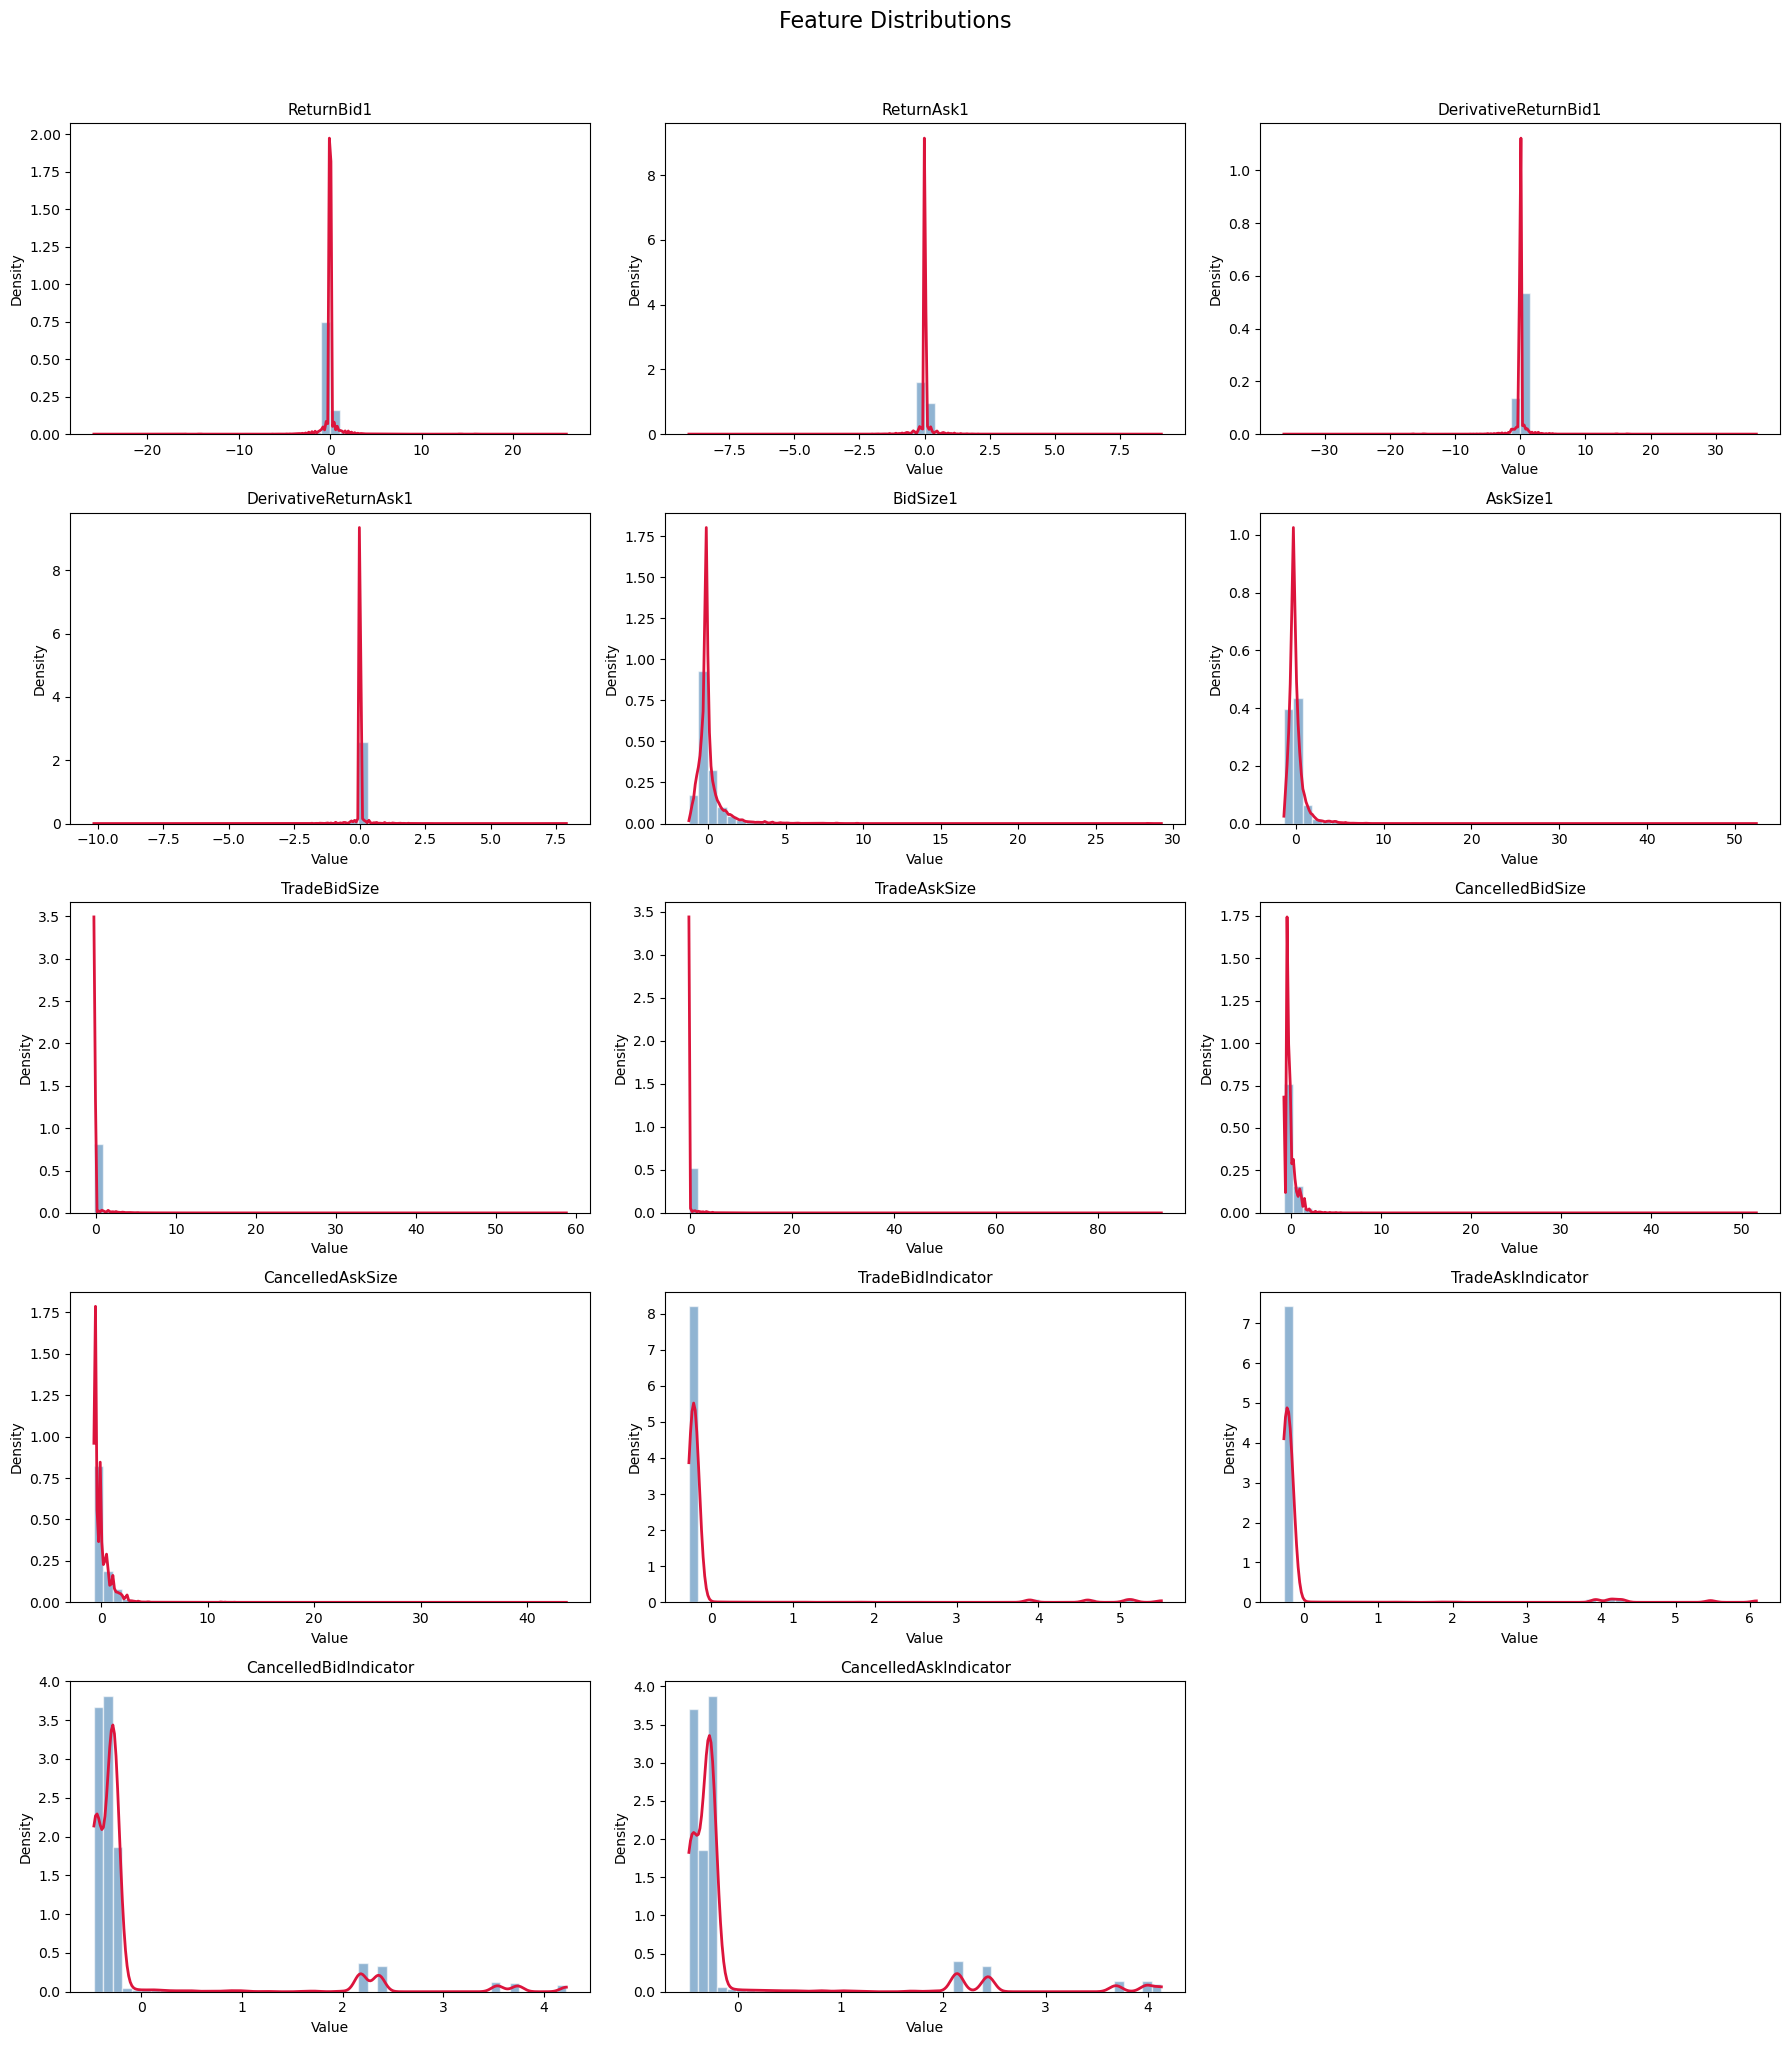

In [46]:
# Grid layout
n_cols = 3
n_rows = int(np.ceil(len(features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(features):
    data = train[col]
    
    # Histogram
    axes[i].hist(data, bins=50, density=True, color='steelblue', alpha=0.6, edgecolor='white')
    
    # KDE line
    kde = gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 300)
    axes[i].plot(x, kde(x), color='crimson', linewidth=2)
    
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Train Autoencoder

### Architecture

In [350]:
scaler = StandardScaler()

X_train = scaler.fit_transform(train[features])  # fit + transform
X_val   = scaler.transform(val[features])         # transform only
X_test  = scaler.transform(test[features])         # transform only

In [376]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

input_dim = X_train.shape[1]

# ── 1. Convert to tensors ──────────────────────────────────────────────────
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val,   dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=2048, shuffle=True)

# ── 2. Model ───────────────────────────────────────────────────────────────
input_dim = X_train.shape[1]  # number of features

class Autoencoder(nn.Module):
    def __init__(self, input_dim, bottleneck=6):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Dropout(0.2),
            nn.Linear(32, bottleneck)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 32),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Dropout(0.2),
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.Dropout(0.2),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = Autoencoder(input_dim, bottleneck=4)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

# ── 4. Training loop ───────────────────────────────────────────────────────
epochs = 100
best_val_loss = float('inf')
best_model_state = None

for epoch in range(epochs):
    # Train
    model.train()
    train_loss = 0
    for (batch,) in train_loader:
        batch = batch.to(device)
        recon = model(batch)
        loss  = nn.MSELoss()(recon, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validate
    model.eval()
    with torch.no_grad():
        val_recon  = model(X_val_tensor.to(device))
        val_loss   = nn.MSELoss()(val_recon, X_val_tensor.to(device)).item()

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()

    scheduler.step()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs}  |  Train Loss: {train_loss:.5f}  |  Val Loss: {val_loss:.5f}")

# ── 5. Load best model ─────────────────────────────────────────────────────
model.load_state_dict(best_model_state)
print(f"\nBest Val Loss: {best_val_loss:.5f}")

Epoch 5/100  |  Train Loss: 0.31983  |  Val Loss: 0.15870
Epoch 10/100  |  Train Loss: 0.30203  |  Val Loss: 0.14654
Epoch 15/100  |  Train Loss: 0.29325  |  Val Loss: 0.14232
Epoch 20/100  |  Train Loss: 0.28715  |  Val Loss: 0.13695
Epoch 25/100  |  Train Loss: 0.28357  |  Val Loss: 0.13335
Epoch 30/100  |  Train Loss: 0.28011  |  Val Loss: 0.13646
Epoch 35/100  |  Train Loss: 0.27839  |  Val Loss: 0.13881
Epoch 40/100  |  Train Loss: 0.27849  |  Val Loss: 0.13242
Epoch 45/100  |  Train Loss: 0.27733  |  Val Loss: 0.13381
Epoch 50/100  |  Train Loss: 0.27638  |  Val Loss: 0.13207
Epoch 55/100  |  Train Loss: 0.27643  |  Val Loss: 0.13864
Epoch 60/100  |  Train Loss: 0.27721  |  Val Loss: 0.13176
Epoch 65/100  |  Train Loss: 0.27661  |  Val Loss: 0.13334
Epoch 70/100  |  Train Loss: 0.27600  |  Val Loss: 0.13031
Epoch 75/100  |  Train Loss: 0.27598  |  Val Loss: 0.13236
Epoch 80/100  |  Train Loss: 0.27401  |  Val Loss: 0.13110
Epoch 85/100  |  Train Loss: 0.27231  |  Val Loss: 0.1304

In [377]:
# Get test reconstruction errors
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    test_recon = model(X_test_tensor)
    test_errors = torch.mean((test_recon - X_test_tensor) ** 2, dim=1).cpu().numpy()
    
test_errors = np.nan_to_num(test_errors,nan=0.0)
# Check for NaNs
print("NaNs in test_errors:", np.isnan(test_errors).sum())

# Normalize to [0, 1]
test_errors_normalized = (test_errors - test_errors.min()) / (test_errors.max() - test_errors.min())

# Submit raw normalized scores — better for AUC-ROC than binary thresholds
submission = pd.DataFrame({
    'ID':     test['index'].values,
    'TARGET': test_errors_normalized
})

submission.to_csv('submission.csv', index=False)
print(f"TARGET range: [{test_errors_normalized.min():.4f}, {test_errors_normalized.max():.4f}]")
print(f"Shape: {submission.shape}")
print(submission.head())

NaNs in test_errors: 0
TARGET range: [0.0000, 1.0000]
Shape: (289101, 2)
   ID  TARGET
0   0     0.0
1   1     0.0
2   2     0.0
3   3     0.0
4   4     0.0


In [378]:
submission.describe()

,ID,TARGET
count,289101.000000,289101.000000
mean,144550.000000,0.003255
std,83456.414424,0.033746
min,0.000000,0.000000
25%,72275.000000,0.000003
50%,144550.000000,0.000008
75%,216825.000000,0.000022
max,289100.000000,1.000000
